<a href="https://colab.research.google.com/github/shivamkumar359/3rd-SEM-CLASS-CODES/blob/main/ML/W4/PRACTICAL_SESSION_PRACTICE-EXAMPLE_BY_MITHUN_DJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# ============================================================
# 2. CREATE A SIMPLE DATASET
# ============================================================
# Example:
# Predict whether a student will PASS based on:
# Study Hours and Attendance

data = {
    "Study_Hours": [1, 2, 2, 3, 3, 4, 5, 5, 6, 7],
    "Attendance":  [50, 55, 60, 65, 70, 72, 80, 85, 90, 95],
    "Pass":        [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
}

df = pd.DataFrame(data)


In [ ]:
print("Dataset:")
print(df)

Dataset:
   Study_Hours  Attendance  Pass
0            1          50     0
1            2          55     0
2            2          60     0
3            3          65     0
4            3          70     1
5            4          72     1
6            5          80     1
7            5          85     1
8            6          90     1
9            7          95     1


In [ ]:
# ============================================================
# 3. SEPARATE INPUT (X) AND OUTPUT (Y)
# ============================================================
X = df[["Study_Hours", "Attendance"]]
y = df["Pass"]
print("\nInput Variables:")
print(X)
print("\nTarget Variable:")
print(y)


Input Variables:
   Study_Hours  Attendance
0            1          50
1            2          55
2            2          60
3            3          65
4            3          70
5            4          72
6            5          80
7            5          85
8            6          90
9            7          95

Target Variable:
0    0
1    0
2    0
3    0
4    1
5    1
6    1
7    1
8    1
9    1
Name: Pass, dtype: int64


In [ ]:
# ============================================================
# 4. SPLIT DATA INTO TRAINING AND TESTING DATA
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\nTraining data:")
print(X_train)

print("\nTesting data:")
print(X_test)



Training data:
   Study_Hours  Attendance
5            4          72
3            3          65
1            2          55
7            5          85
9            7          95
4            3          70
0            1          50

Testing data:
   Study_Hours  Attendance
2            2          60
8            6          90
6            5          80


In [ ]:
# ============================================================
# 5. CREATE DECISION TREE
# ============================================================
# criterion="gini" --> CART
#
# CART commonly uses Gini Impurity.
#
# criterion="entropy" --> Entropy / Information Gain
# This is commonly associated with ID3-style splitting.
#
# max_depth controls how deep the tree can grow.
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

In [ ]:
# ============================================================
# 6. TRAIN THE MODEL
# ============================================================
model.fit(X_train, y_train)
print("\nDecision Tree trained successfully!")


Decision Tree trained successfully!


In [ ]:
# ============================================================
# 7. MAKE PREDICTIONS
# ============================================================
y_pred = model.predict(X_test)
print("\nActual values:")
print(y_test.values)
print("\nPredicted values:")
print(y_pred)


Actual values:
[0 1 1]

Predicted values:
[0 1 1]


In [ ]:
# ============================================================
# 8. CHECK ACCURACY
# ============================================================
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)


Accuracy: 1.0


In [ ]:
# ============================================================
# 9. CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



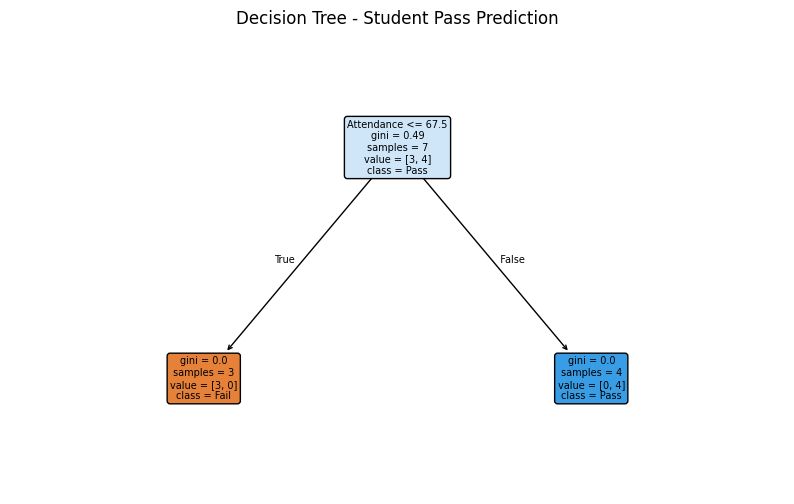

In [ ]:
# ============================================================
# 10. VISUALIZE THE DECISION TREE
# ============================================================
# This shows the rules learned by the model.
#
# samples = number of observations reaching that node
# gini    = impurity of the node
# class   = predicted class

plt.figure(figsize=(10, 6))

plot_tree(
    model,
    feature_names=["Study_Hours", "Attendance"],
    class_names=["Fail", "Pass"],
    filled=True,
    fontsize=7,
    rounded=True
)

plt.title("Decision Tree - Student Pass Prediction")

plt.show()

In [ ]:
# ============================================================
# 11. PREDICT A NEW STUDENT
# ============================================================
# New student:
# Study Hours = 4
# Attendance  = 75%
new_student = [[4, 75]]

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("\nNew Student Prediction: PASS")
else:
    print("\nNew Student Prediction: FAIL")


New Student Prediction: PASS


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# 12. PREDICT PROBABILITY
# ============================================================
# predict_proba gives probability for each class.
probability = model.predict_proba(new_student)
print("\nProbability:")
print("Fail:", probability[0][0])
print("Pass:", probability[0][1])


Probability:
Fail: 0.0
Pass: 1.0


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ============================================================
# 13. FIND FEATURE IMPORTANCE
# ============================================================
# Feature importance tells us which variable
# contributed more to the decision tree.

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print("\nFeature Importance:")
print(importance)


Feature Importance:
       Feature  Importance
0  Study_Hours         0.0
1   Attendance         1.0


In [ ]:
# ============================================================
# 14. COMPARE CART AND ID3-STYLE TREE
# ============================================================

# CART --> Gini Impurity
cart_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

cart_model.fit(X_train, y_train)


# ID3-style --> Entropy / Information Gain
id3_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

id3_model.fit(X_train, y_train)


# Predictions
cart_pred = cart_model.predict(X_test)
id3_pred = id3_model.predict(X_test)

print("\nCART Accuracy:",
      accuracy_score(y_test, cart_pred))

print("Entropy / ID3-style Accuracy:",
      accuracy_score(y_test, id3_pred))


CART Accuracy: 1.0
Entropy / ID3-style Accuracy: 1.0
